In [ ]:
# Анализ поведения игроков в онлайн-играх

In [ ]:
# Блок 1: импорт библиотек

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config Completer.use_jedi = False

In [ ]:
# Блок 2: загрузка данных

In [3]:
df = pd.read_csv('online_gaming_behavior_dataset.csv')

In [6]:
print(f"Данные загружены. Размер: {df.shape[0]} строк, {df.shape[1]} столбцов.")
print(f"Пропуски: {df.isnull().sum().sum()}")
print(f"Уникальных игроков: {df['PlayerID'].nunique()}")

Данные загружены. Размер: 40034 строк, 13 столбцов.
Пропуски: 0
Уникальных игроков: 40034


In [10]:
# Первичный взгляд на данные
df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [ ]:
# Блок 3: портрет игрока

In [11]:
# 3.1 Гендерное распределение
gender_counts = df['Gender'].value_counts()
print("Гендерное распределение")
print(gender_counts)

Гендерное распределение
Gender
Male      23959
Female    16075
Name: count, dtype: int64


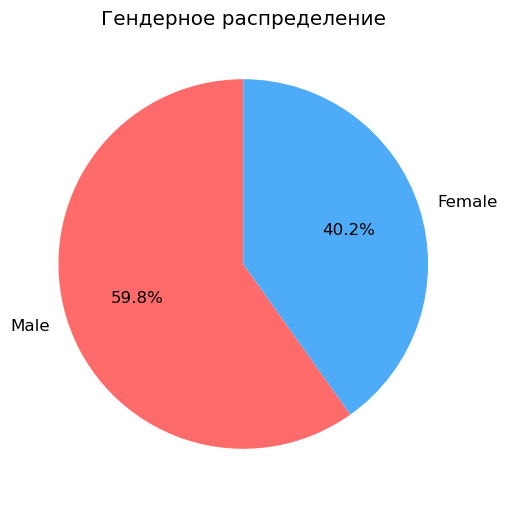

In [125]:
gender_counts.plot(kind='pie', startangle = 90, autopct='%1.1f%%',  colors=['#ff6b6b', '#4dabf7'])
plt.title('Гендерное распределение')
plt.ylabel('')  
plt.show()

In [119]:
# Соотношение полов в игре — 60% мужчин и 40% женщин.

In [120]:
# 2.2 Распределение по возрасту 
print("Возрастное распределение")
print(f"Средний возраст: {df['Age'].mean():.1f}")
print(f"Медианный возраст: {df['Age'].median():.1f}")
print(f"Мин/Макс: {df['Age'].min()}/{df['Age'].max()}")

Возрастное распределение
Средний возраст: 32.0
Медианный возраст: 32.0
Мин/Макс: 15/49


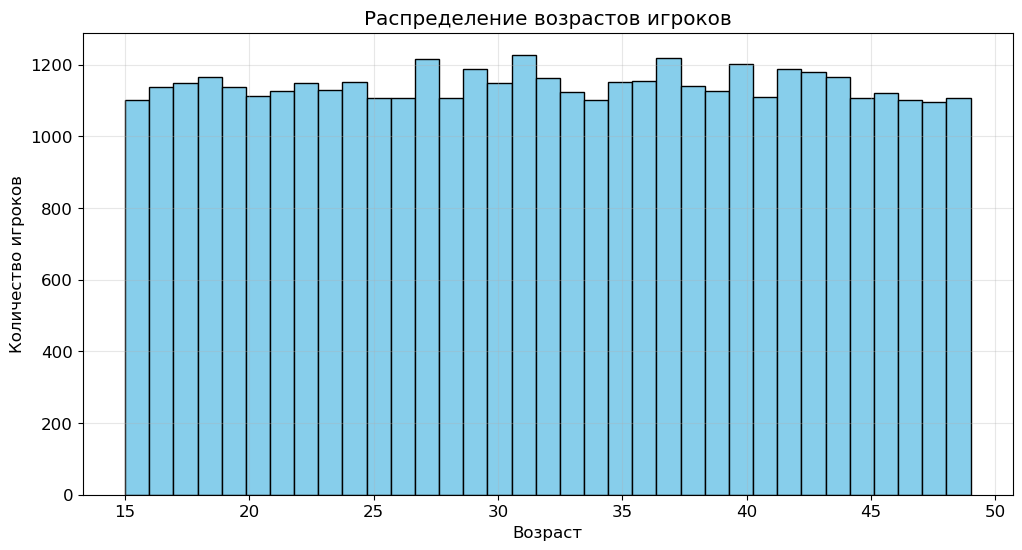

In [38]:
df['Age'].plot(kind='hist', bins=35, edgecolor='black', color='skyblue')
plt.title('Распределение возрастов игроков')
plt.xlabel('Возраст')
plt.ylabel('Количество игроков')
plt.show()

In [ ]:
# Возраст равномерно распределен от 15 до 49 лет.

In [39]:
# 2.3 Региональное распределение 
print("Региональное распределение")
region_counts = df['Location'].value_counts()
print(region_counts)

Региональное распределение
Location
USA       16000
Europe    12004
Asia       8095
Other      3935
Name: count, dtype: int64


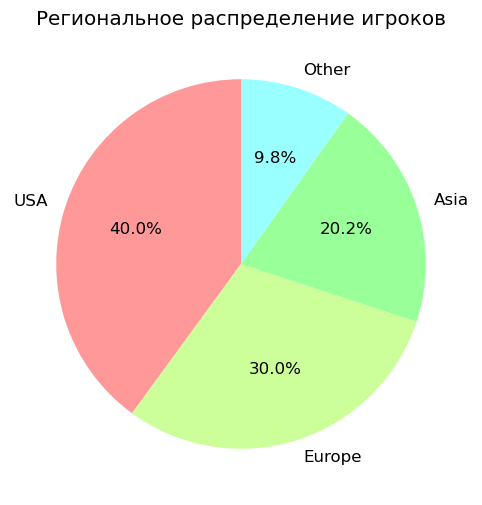

In [45]:
region_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff9999', '#ccff99', '#99ff99', '#99ffff', '#cc99ff']
)
plt.title('Региональное распределение игроков')
plt.ylabel('')
plt.show()

In [ ]:
# США (40%), Европа (30%), Азия (20%), Другие (10%).

In [ ]:
# Блок 3: проверка гипотез

In [47]:
# 3.1 Гипотеза №1: игроки из Азии играют дольше за сессию, но реже
print("Гипотеза №1: региональные различия")

region_behavior = df.groupby('Location')[['SessionsPerWeek', 'AvgSessionDurationMinutes']].mean().round(1)
print(region_behavior)

Гипотеза №1: региональные различия
          SessionsPerWeek  AvgSessionDurationMinutes
Location                                            
Asia                  9.5                       94.8
Europe                9.5                       94.2
Other                 9.4                       94.9
USA                   9.5                       95.2


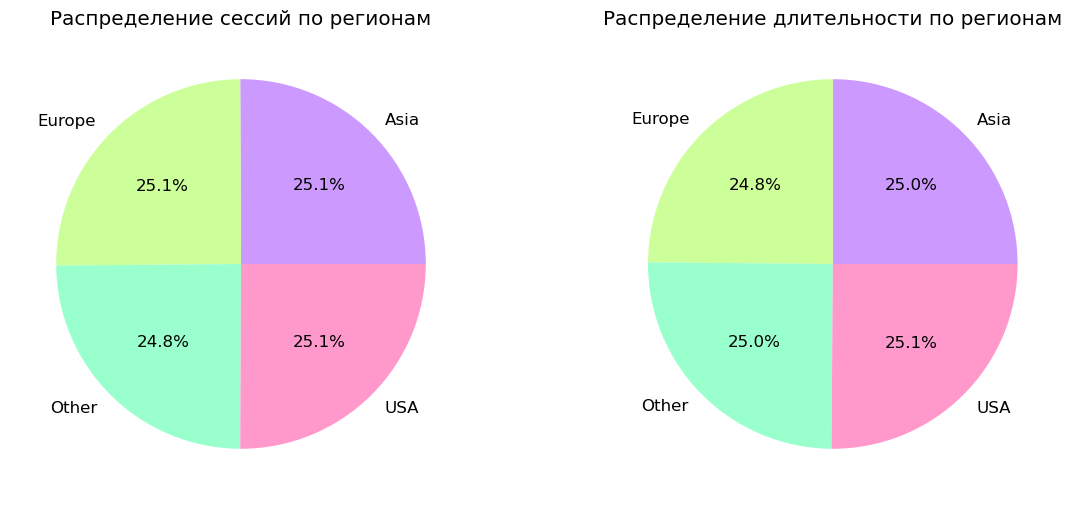

In [63]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

region_behavior['SessionsPerWeek'].plot(kind='pie', autopct='%1.1f%%', ax=ax1, colors=['#cc99ff', '#ccff99', '#99ffcc', '#ff99cc'])
ax1.set_title('Распределение сессий по регионам')
ax1.set_ylabel('')

region_behavior['AvgSessionDurationMinutes'].plot(kind='pie', autopct='%1.1f%%', ax=ax2, colors=['#cc99ff', '#ccff99', '#99ffcc', '#ff99cc'])
ax2.set_title('Распределение длительности по регионам')
ax2.set_ylabel('')

plt.show()

In [ ]:
# Вопреки ожиданиям, региональные различия в игровом поведении оказались минимальны: 
# все регионы показывают ~9.5 сессий в неделю и ~95 минут на сессию.

In [85]:
# 3.2 Гипотеза №2: cложность игры влияет на траты
print("Гипотеза №2: сложность игры и траты")

difficulty_stats = df.groupby('GameDifficulty').agg({
    'PlayerID': 'count',
    'PlayTimeHours': 'mean',
    'InGamePurchases': 'mean'
}).round(4)
difficulty_stats.columns = ['Количество', 'Среднее время', 'Конверсия']
difficulty_stats['Конверсия'] = (difficulty_stats['Конверсия'] * 100.0).round(2)
print(difficulty_stats)

Гипотеза №2: сложность игры и траты
                Количество  Среднее время  Конверсия
GameDifficulty                                      
Easy                 20015        12.0126      19.96
Hard                  8008        12.0390      19.99
Medium               12011        12.0343      20.36


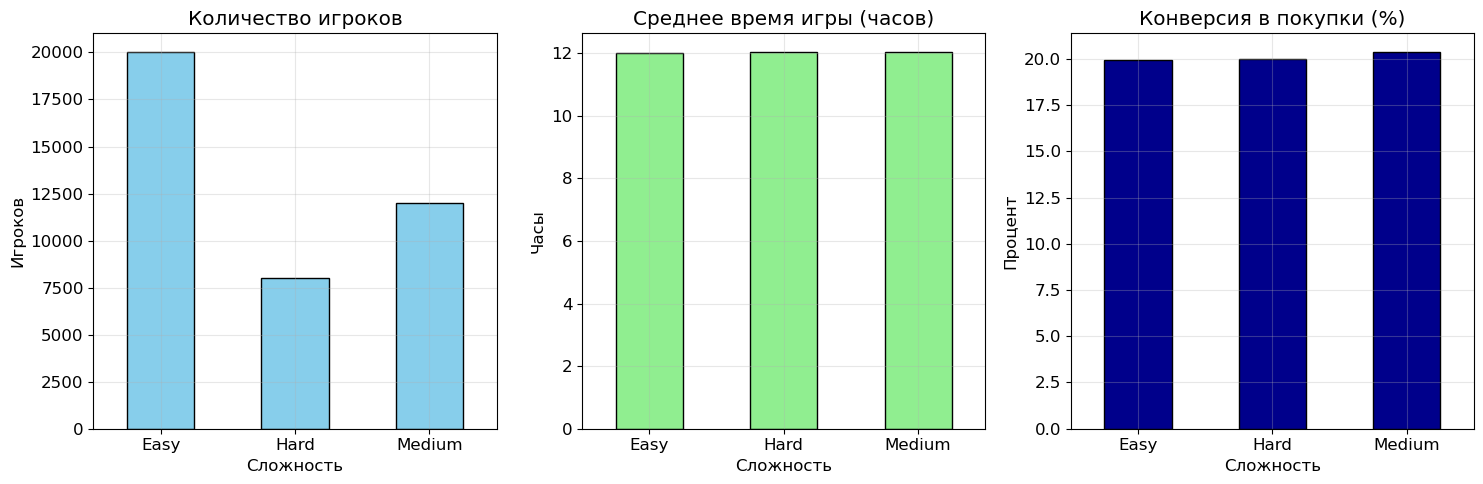

In [90]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# График 1: Количество игроков
difficulty_stats['Количество'].plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Количество игроков')
ax1.set_xlabel('Сложность')
ax1.set_ylabel('Игроков')
ax1.tick_params(axis='x', rotation=0)
ax1.grid(axis='y', alpha=0.3)

# График 2: Среднее время игры
difficulty_stats['Среднее время'].plot(kind='bar', ax=ax2, color='lightgreen', edgecolor='black')
ax2.set_title('Среднее время игры (часов)')
ax2.set_xlabel('Сложность')
ax2.set_ylabel('Часы')
ax2.tick_params(axis='x', rotation=0)
ax2.grid(axis='y', alpha=0.3)

# График 3: Конверсия в покупки (%)
difficulty_stats['Конверсия'].plot(kind='bar', ax=ax3, color='darkblue', edgecolor='black')
ax3.set_title('Конверсия в покупки (%)')
ax3.set_xlabel('Сложность')
ax3.set_ylabel('Процент')
ax3.tick_params(axis='x', rotation=0)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Анализ показал, что сложность игры не влияет на ключевые метрики: 
# среднее время игры и конверсия в покупку одинаковы для всех уровней сложности. 
# Единственное отличие — размер аудитории: Easy-игроков в 2.5 раза больше, чем Hard-игроков.

In [87]:
# 3.3 Гипотеза №3: достижения влияют на вовлеченность
print("Гипотеза №3: достижения и вовлеченность")

engagement_stats = df.groupby('EngagementLevel').agg({
    'PlayerID': 'count',
    'AchievementsUnlocked': 'mean',
    'SessionsPerWeek': 'mean'
}).round(1)
engagement_stats.columns = ['Количество', 'Достижения', 'Сессии в неделю']
print(engagement_stats)

Гипотеза №3: достижения и вовлеченность
                 Количество  Достижения  Сессии в неделю
EngagementLevel                                         
High                  10336        25.1             14.3
Low                   10324        22.7              4.5
Medium                19374        25.2              9.6


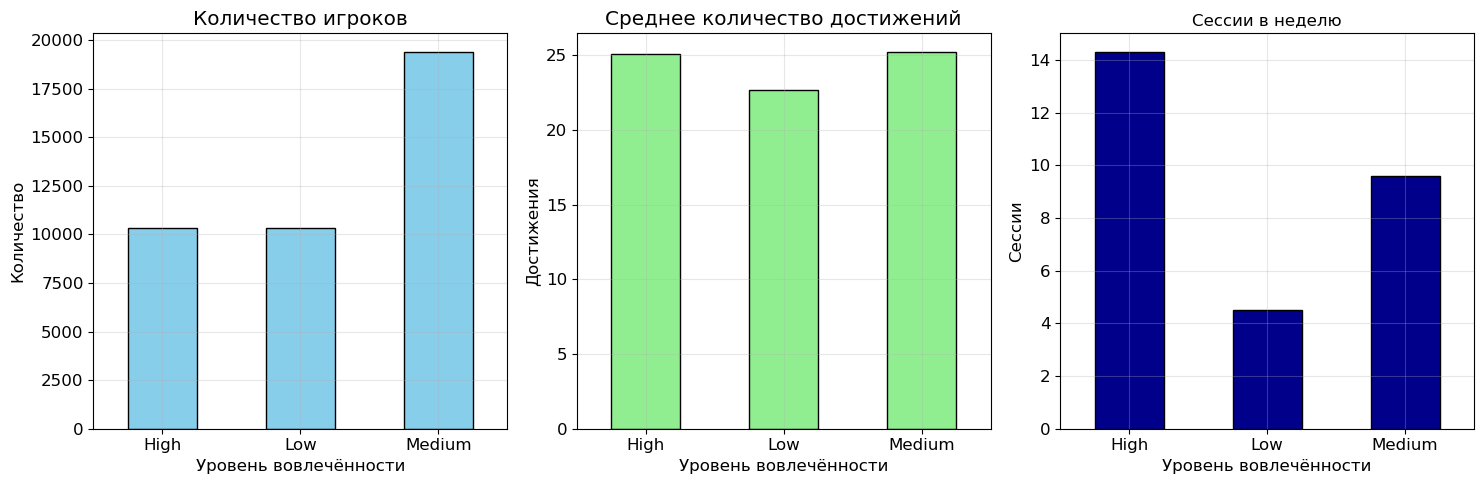

In [91]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# График 1: Количество игроков
engagement_stats['Количество'].plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Количество игроков')
ax1.set_xlabel('Уровень вовлечённости')
ax1.set_ylabel('Количество')
ax1.tick_params(axis='x', rotation=0)
ax1.grid(axis='y', alpha=0.3)


# График 2: Среднее количество достижений
engagement_stats['Достижения'].plot(kind='bar', ax=ax2, color='lightgreen', edgecolor='black')
ax2.set_title('Среднее количество достижений')
ax2.set_xlabel('Уровень вовлечённости')
ax2.set_ylabel('Достижения')
ax2.tick_params(axis='x', rotation=0)
ax2.grid(axis='y', alpha=0.3)

# График 3: Сессии в неделю
engagement_stats['Сессии в неделю'].plot(kind='bar', ax=ax3, color='darkblue', edgecolor='black')
ax3.set_title('Сессии в неделю', fontsize=12)
ax3.set_xlabel('Уровень вовлечённости')
ax3.set_ylabel('Сессии')
ax3.tick_params(axis='x', rotation=0)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Игроки с высокой вовлеченностью (High) проводят в игре в 3 раза больше сессий, чем Low-игроки (14.3 vs 4.5). 
# При этом количество достижений и уровень персонажа у High и Medium почти одинаковы. 
# Это говорит о том, что вовлченные игроки чаще заходят в игру.

In [100]:
# 3.4 Гипотеза №4: уровень сложности влияет на вовлеченность
print("Гипотеза №4: сложность и вовлеченность")

difficulty_engagement = pd.crosstab(df['GameDifficulty'], df['EngagementLevel'], normalize='index') * 100
print(difficulty_engagement.round(1))

Гипотеза №4: сложность и вовлеченность
EngagementLevel  High   Low  Medium
GameDifficulty                     
Easy             25.6  26.0    48.3
Hard             26.4  25.9    47.7
Medium           25.7  25.3    48.9


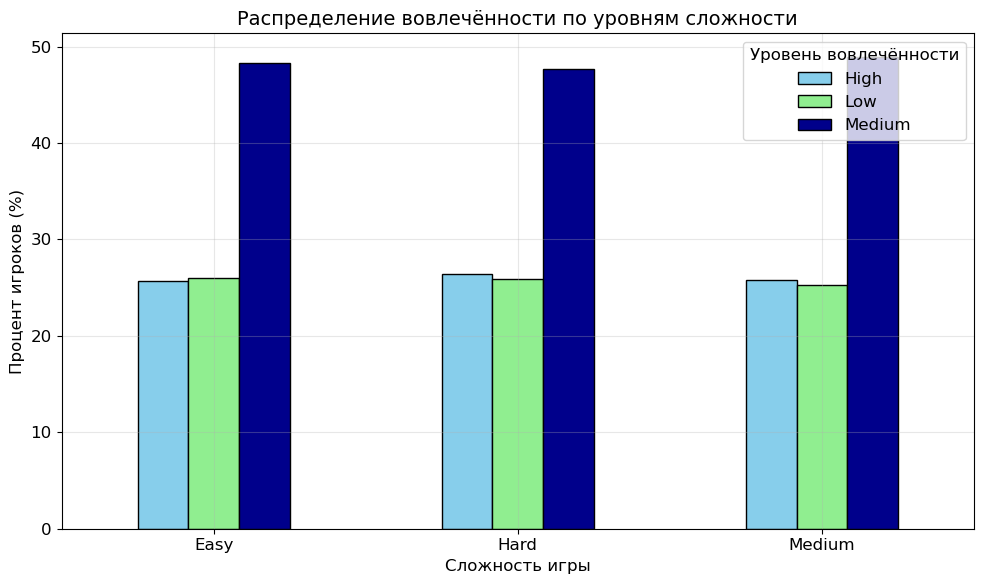

In [110]:
difficulty_engagement.plot(kind='bar', figsize=(10, 6), edgecolor='black', color=['skyblue', 'lightgreen', 'darkblue'])
plt.title('Распределение вовлечённости по уровням сложности', fontsize=14)
plt.xlabel('Сложность игры', fontsize=12)
plt.ylabel('Процент игроков (%)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Уровень вовлечённости')
plt.tight_layout()
plt.show()

In [ ]:
# Распределение вовлеченности одинаково для всех уровней сложности: ~26% High, ~26% Low, ~48% Medium везде

In [111]:
# 3.5 Гипотеза №5: мужчины чаще играют в Action и Sports, а женщины — в RPG и Simulation.
print("Гипотеза №5: гендерные предпочтения в жанрах")

genre_gender = pd.crosstab(df['GameGenre'], df['Gender'], normalize='index') * 100
print(genre_gender.round(1))

Гипотеза №5: гендерные предпочтения в жанрах
Gender      Female  Male
GameGenre               
Action        39.2  60.8
RPG           40.7  59.3
Simulation    40.3  59.7
Sports        40.3  59.7
Strategy      40.3  59.7


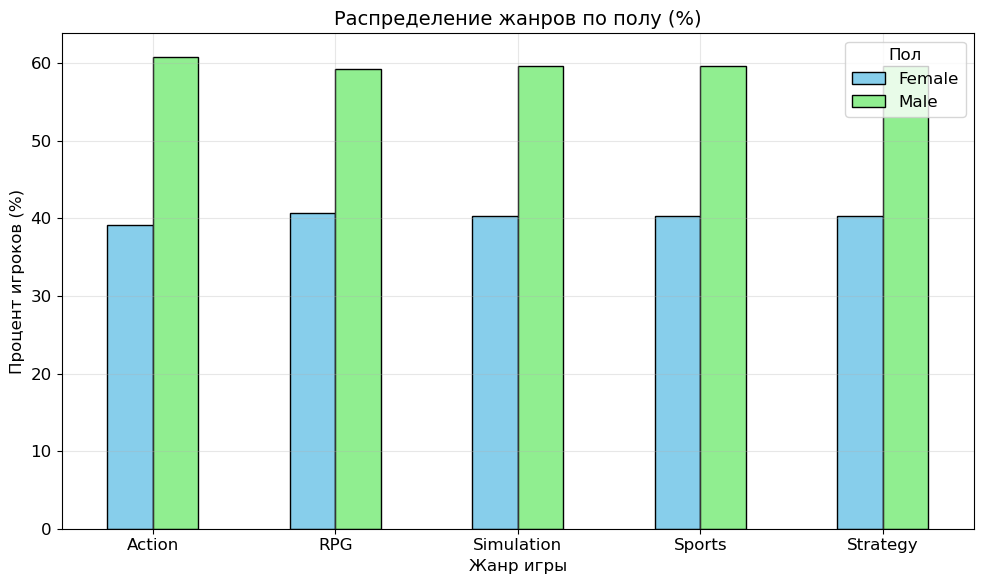

In [116]:
genre_gender.plot(kind='bar', figsize=(10, 6), edgecolor='black', color=['skyblue', 'lightgreen'])
plt.title('Распределение жанров по полу (%)', fontsize=14)
plt.xlabel('Жанр игры', fontsize=12)
plt.ylabel('Процент игроков (%)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Пол')
plt.tight_layout()
plt.show()

In [ ]:
# Во всех жанрах одинаковое соотношение полов: ~60% мужчин, ~40% женщин. Никаких жанровых предпочтений нет.

In [ ]:
# Вывод по гипотезам 

# Из пяти проверенных гипотез только одна (о связи достижений и вовлеченности)
# показала статистически значимую корреляцию. Остальные гипотезы не подтвердились —
# все исследованные факторы (регион, сложность, жанр) не влияют на поведение игроков.

# Это может быть связано с синтетической природой датасета, где зависимости 
# не были заложены искусственно.